# DC Motor Speed Control

This notebook demonstrates how to use the simulation framework to model and control a DC Motor. We will:
1. Implement a custom continuous-time `DCMotorPlant`.
2. Configure a simulation with a PID controller, Gaussian sensor noise, and a step reference.
3. Run the simulation and visualize the results.

## 1. The DC Motor Plant

The DC motor is modeled by the following differential equations:
- $L \frac{di}{dt} = -Ri - K_e \omega + V$
- $J \frac{d\omega}{dt} = K_t i - b \omega$

Where:
- $x = [\omega, i]^T$ is the state vector (speed and armature current).
- $u = V$ is the control input (voltage).
- $y = \omega$ is the measured output.

In [37]:
import importlib
from typing import Any, Self

import numpy as np
from pydantic import BaseModel, ConfigDict

from simulate.plant import Plant


class DCMotorLog(BaseModel):
    """Pydantic model for logging DC Motor internal state."""

    model_config = ConfigDict(arbitrary_types_allowed=True)

    omega: float
    current: float


class DCMotorPlant(Plant[DCMotorLog]):
    """Custom DC Motor plant implementation."""

    def __init__(  # noqa: PLR0913
        self,
        dt: float,
        R: float,  # noqa: N803
        L: float,  # noqa: N803
        Ke: float,  # noqa: N803
        Kt: float,  # noqa: N803
        J: float,  # noqa: N803
        b: float,
        integrator: Any = None,  # noqa: ANN401
    ) -> None:
        super().__init__(dt, integrator)
        self.R = R
        self.L = L
        self.Ke = Ke
        self.Kt = Kt
        self.J = J
        self.b = b

        # Initialize state: [omega, i]
        self.x = np.zeros((2, 1))

    @classmethod
    def from_config(cls, config: dict[str, Any]) -> Self:
        """Load parameters from configuration dictionary."""
        integrator = config.get("integrator")
        if isinstance(integrator, str):
            module_name, func_name = integrator.rsplit(".", 1)
            module = importlib.import_module(module_name)
            integrator = getattr(module, func_name)

        return cls(
            dt=float(config["dt"]),
            R=config["R"],
            L=config["L"],
            Ke=config["Ke"],
            Kt=config["Kt"],
            J=config["J"],
            b=config["b"],
            integrator=integrator,
        )

    def dynamics(self, t: float, x: np.ndarray, u: np.ndarray) -> np.ndarray:  # noqa: ARG002
        """Continuous-time dynamics x_dot = f(t, x, u)."""
        omega = x[0, 0]
        i = x[1, 0]
        V = u[0, 0]  # noqa: N806

        d_omega = (self.Kt * i - self.b * omega) / self.J
        d_i = (-self.R * i - self.Ke * omega + V) / self.L

        return np.array([[d_omega], [d_i]])

    def update(self, t: float, u: float | np.ndarray) -> tuple[float | np.ndarray, DCMotorLog]:
        """Step the plant dynamics forward using the assigned integrator."""
        u_vec = self.to_col_vec(u)

        if self.integrator is not None:
            self.x = self.integrator(self.dynamics, t, self.dt, self.x, u_vec)

        omega = float(self.x[0, 0])
        i = float(self.x[1, 0])
        return omega, DCMotorLog(omega=omega, current=i)

    def step(self, t: float, u: float | np.ndarray) -> tuple[float | np.ndarray, DCMotorLog]:
        """Public step method with Zero-Order Hold (ZOH) enforcement."""
        return self._execute_zoh(t, self.update, u)

## 2. Configuration Setup

We define the simulation parameters in a dictionary. Note that the `class_path` for our custom plant uses `__main__` because the class is defined in this notebook.

In [38]:
config = {
    "t_end": 2.0,
    "plant": {
        "class_path": "__main__.DCMotorPlant",
        "dt": 0.001,
        "R": 1.0,
        "L": 0.01,
        "Ke": 0.05,
        "Kt": 0.05,
        "J": 0.001,
        "b": 0.001,
        "integrator": "simulate.integrator.rk4",
    },
    "reference": {
        "class_path": "simulate.reference.StepReference",
        "dt": 0.001,
        "step_value": 100.0,
        "start_time": 0.5,
    },
    "sensor": {"class_path": "simulate.sensor.GaussianSensor", "dt": 0.001, "std_dev": 0.1},
    "estimator": {"class_path": "simulate.estimator.IdentityEstimator", "dt": 0.001},
    "controller": {
        "class_path": "simulate.controller.PIDController",
        "dt": 0.001,
        "kp": [[1.0]],
        "ki": [[2.0]],
        "kd": [[0.00]],
    },
}

## 3. Running the Simulation

In [39]:
from simulate.simulation import Simulation

sim = Simulation.from_config(config)
sim.run()

## 4. Visualizing Results

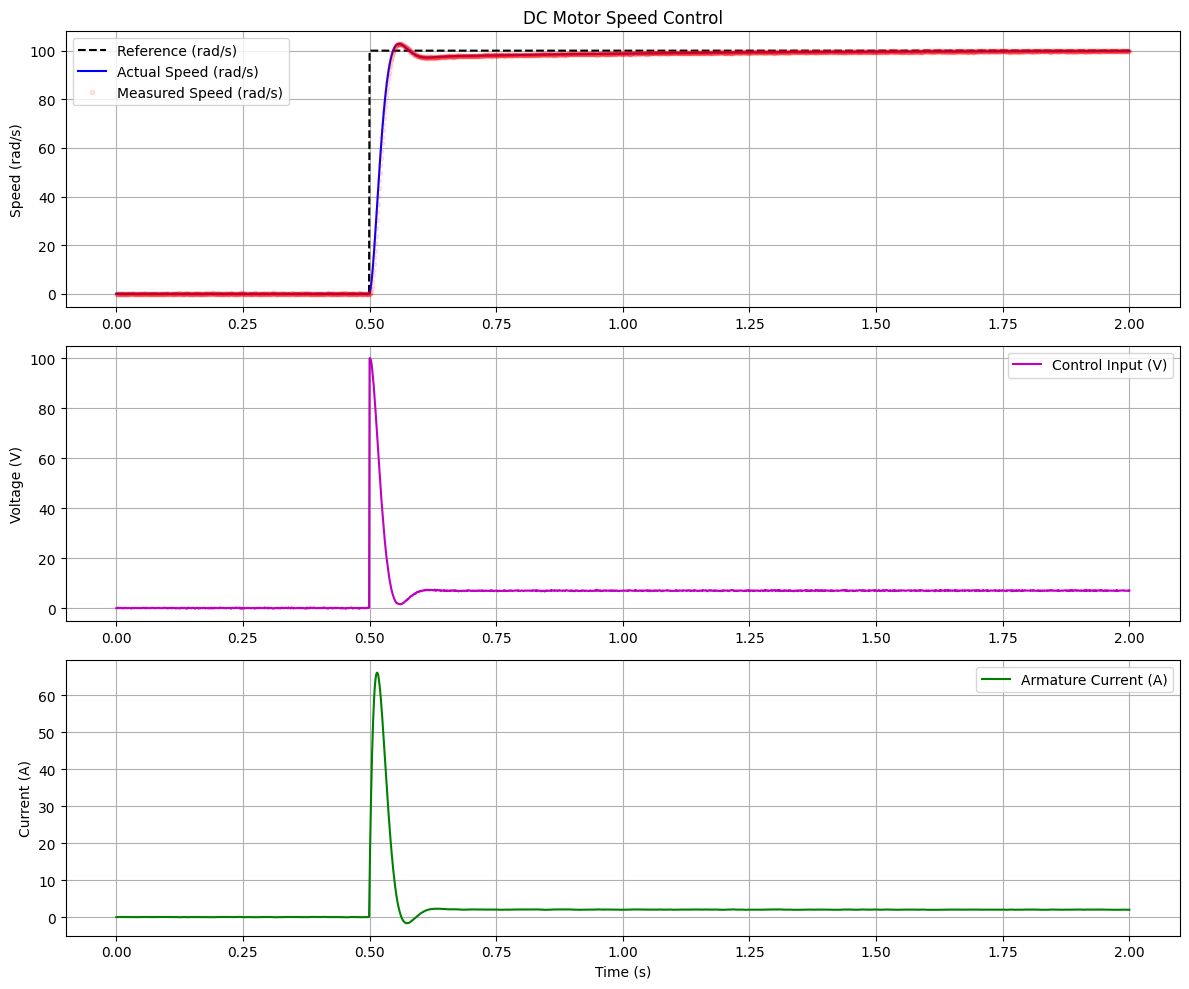

In [40]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract logs into DataFrames
data = pd.DataFrame(sim.logger.universal_logs)
plant_data = pd.DataFrame(sim.logger.component_logs["plant"])

plt.figure(figsize=(12, 10))

plt.subplot(3, 1, 1)
plt.plot(data["t"], data["ref"], "k--", label="Reference (rad/s)")
plt.plot(data["t"], data["y"], "b-", label="Actual Speed (rad/s)")
plt.plot(data["t"], data["y_mea"], "r.", alpha=0.1, label="Measured Speed (rad/s)")
plt.title("DC Motor Speed Control")
plt.ylabel("Speed (rad/s)")
plt.legend()
plt.grid(True)  # noqa: FBT003

plt.subplot(3, 1, 2)
plt.plot(data["t"], data["u"], "m-", label="Control Input (V)")
plt.ylabel("Voltage (V)")
plt.legend()
plt.grid(True)  # noqa: FBT003

plt.subplot(3, 1, 3)
plt.plot(data["t"], plant_data["current"], "g-", label="Armature Current (A)")
plt.xlabel("Time (s)")
plt.ylabel("Current (A)")
plt.legend()
plt.grid(True)  # noqa: FBT003

plt.tight_layout()
plt.show()